In [36]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import OptimalBattery.global_config as gcf
from scipy.stats import ttest_rel

save_dir = gcf.save_dir

In [37]:
# load tsv with eval data
eval_tsvs_dir = os.path.abspath(os.path.join(os.getcwd(),'..','eval_tsvs'))
saved_file = os.path.join(eval_tsvs_dir, 'real_parcellation_cortex_org.tsv')
D = pd.read_csv(saved_file, sep='\t')

In [38]:
# defube metrics to plot
metrics = ['random','variance','inverse_trace_mc','log_det_mc']
D = D[D['metric'].isin(metrics)]
n_subs = 24
D["sub"] = (D.index % n_subs) + 1
D = D[D['roi']=='All Parcels']

In [46]:
results = []

for n in D['n_task'].unique():
    sub_df = D[D['n_task'] == n]

    a = sub_df[sub_df['metric'] == 'log_det_mc'].sort_values('sub')['avg_cos_sim_per_subject']
    b = sub_df[sub_df['metric'] == 'variance'].sort_values('sub')['avg_cos_sim_per_subject']

    # Only run if both have the same subjects
    if len(a) == len(b):
        t, p = ttest_rel(a, b)
        results.append([n, t, p])

res_df = pd.DataFrame(results, columns=['n_task', 't', 'p'])
print(res_df)

    n_task          t             p
0        3   3.987939  5.796432e-04
1        4   7.333244  1.846132e-07
2        5  11.849230  2.843384e-11
3        6   8.083000  3.591450e-08
4        7   8.945226  5.994684e-09
5        8   8.241240  2.566689e-08
6        9   8.070715  3.686863e-08
7       10   8.892598  6.668162e-09
8       11   7.228106  2.336441e-07
9       12   3.749031  1.046924e-03
10      13   9.119825  4.221614e-09
11      14   3.841451  8.333167e-04
12      15   5.955595  4.512826e-06
13      16   7.995708  4.328863e-08


In [47]:
results = []

for n in D['n_task'].unique():
    sub_df = D[D['n_task'] == n]

    a = sub_df[sub_df['metric'] == 'log_det_mc'].sort_values('sub')['avg_cos_sim_per_subject']
    b = sub_df[sub_df['metric'] == 'inverse_trace_mc'].sort_values('sub')['avg_cos_sim_per_subject']

    # Only run if both have the same subjects
    if len(a) == len(b):
        t, p = ttest_rel(a, b)
        results.append([n, t, p])

res_df = pd.DataFrame(results, columns=['n_task', 't', 'p'])
print(res_df)

    n_task         t         p
0        3  0.453194  0.654656
1        4 -3.298658  0.003140
2        5  4.902177  0.000059
3        6  3.227482  0.003726
4        7  5.313869  0.000021
5        8  4.584120  0.000131
6        9  2.330870  0.028888
7       10  3.269000  0.003372
8       11  2.434731  0.023073
9       12 -2.851386  0.009034
10      13  6.015161  0.000004
11      14  0.348037  0.730978
12      15  1.041114  0.308644
13      16  5.128842  0.000034


In [40]:
custom_palette = {
    'random': 'black',
    'variance': '#0072B2',
    'variance_mc': '#009E73',
    'log_det_mc': '#E69F00',
    'inverse_trace_mc': '#D55E00'
}

custom_dashes = {
    'random': '',            
    'variance': '',              
    'variance_mc': '',          
    'log_det_mc': '',        # solid
    'inverse_trace_mc': '',  # solid
}

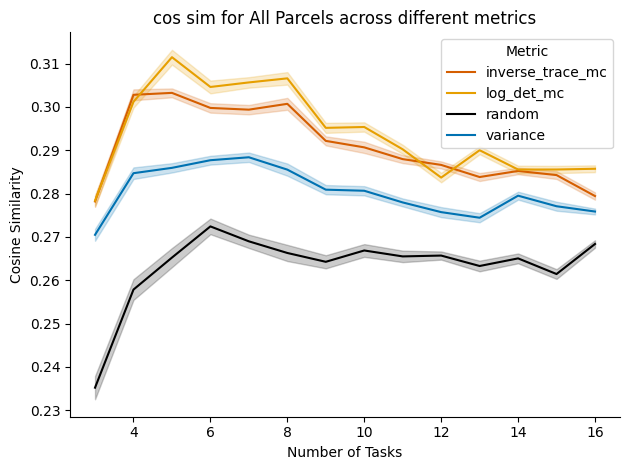

In [41]:
# check unique ROIs
rois = D['roi'].unique()
for roi in rois:
    df_roi = D[D['roi'] == roi]

    # Step 1: compute the group mean per n_task
    task_mean = df_roi.groupby("n_task")["avg_cos_sim_per_subject"].transform("mean")

    # Step 2: compute each subject’s mean within that n_task
    subject_mean = df_roi.groupby(["n_task", "sub"])["avg_cos_sim_per_subject"].transform("mean")

    # Step 3 & 4: remove subject effect, add group mean
    df_roi["adjusted"] = df_roi["avg_cos_sim_per_subject"] - subject_mean + task_mean

    sns.lineplot(
        data=df_roi,
        x="n_task",
        y="adjusted",
        hue="metric",
        style="metric",
        errorbar='se',
        palette=custom_palette,
        dashes=custom_dashes,
    )


    plt.xlabel("Number of Tasks")
    plt.ylabel("Cosine Similarity")
    plt.title(f"cos sim for {roi} across different metrics")
    sns.despine()
    plt.legend(title="Metric")
    plt.tight_layout()
    plt.savefig(f"{save_dir}/battery_criteria/real_cortical_{roi}.pdf", format="pdf", bbox_inches="tight")
    plt.show()